# Classification de maladies des plantes

Projet Deep Learning pour reconnaitre des maladies de plantes a partir d'une photo de feuille.

Voici le plan qu'on va suivre, etape par etape :

1. On choisit un dataset (PlantVillage)
2. On adapte ses dimensions et son nombre de classes
3. On teste un reseau dense tout simple
4. On passe au CNN, et on compare deux versions
5. On construit un ResNet a la main
6. On termine avec du transfer learning

Tout au long du notebook, on applique des techniques de regularisation pour eviter le surapprentissage.


### Preparation de l'environnement

In [17]:
import tensorflow as tf

# On regarde si un GPU est dispo
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # On evite que TF reserve toute la VRAM d'un coup (utile sur les petits GPU)
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU detecte :", gpus[0].name)
else:
    print("Pas de GPU, on tourne sur CPU (ca marche, c'est juste plus lent)")

print("Version de TensorFlow :", tf.__version__)

GPU detecte : /physical_device:GPU:0
Version de TensorFlow : 2.10.0


In [18]:
from pathlib import Path

DATA_DIR = Path("data/PlantVillage")
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dossier introuvable : {DATA_DIR}\n"
    )

nb_dossiers = len([d for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Dataset trouve : {nb_dossiers} classes dans {DATA_DIR}")

Dataset trouve : 38 classes dans data\PlantVillage


### On adapte le dataset

Le dataset complet a 38 classes et des images en 256x256. Pour que ca tourne vite, je fait deux changements :

- on garde seulement 10 classes (un melange de plantes saines et malades)
- on reduit les images a 128x128


In [19]:
IMG_SIZE = 128       # taille des images
BATCH_SIZE = 32      
SEED = 42            

# On choisit 10 classes variees 5 plantes, chacune saine et malade
CLASSES_CHOISIES = [
    "Apple___healthy",
    "Apple___Apple_scab",
    "Corn_(maize)___healthy",
    "Corn_(maize)___Common_rust_",
    "Grape___healthy",
    "Grape___Black_rot",
    "Potato___healthy",
    "Potato___Late_blight",
    "Tomato___healthy",
    "Tomato___Bacterial_spot",
]

NB_CLASSES = len(CLASSES_CHOISIES)
print(f" {NB_CLASSES} classes :")
for i, c in enumerate(CLASSES_CHOISIES):
    print(f"  {i} : {c}")

 10 classes :
  0 : Apple___healthy
  1 : Apple___Apple_scab
  2 : Corn_(maize)___healthy
  3 : Corn_(maize)___Common_rust_
  4 : Grape___healthy
  5 : Grape___Black_rot
  6 : Potato___healthy
  7 : Potato___Late_blight
  8 : Tomato___healthy
  9 : Tomato___Bacterial_spot


In [20]:
import shutil

# On copie les 10 classes qui nous interessent dans un nouveau dossier
SOUS_DATASET = Path("data/dataset_10classes")

if not SOUS_DATASET.exists():
    print("Creation du sous-dataset...")
    for nom_classe in CLASSES_CHOISIES:
        source = DATA_DIR / nom_classe
        destination = SOUS_DATASET / nom_classe
        if source.exists():
            shutil.copytree(source, destination)
            nb = len(list(destination.glob("*.*")))
            print(f"  {nom_classe} : {nb} images copiees")
        else:
            print(f"  Attention, {nom_classe} introuvable")
else:
    print("Le sous-dataset existe deja")

Le sous-dataset existe deja


### Chargement et decoupage train / validation / test

On utilise image_dataset_from_directory, qui lit directement les images depuis les dossiers et leur attribue un label selon le nom du dossier.

On decoupe en trois paquets : 70% pour l'entrainement, 15% pour la validation, 15% pour le test final.

In [21]:
from tensorflow.keras.utils import image_dataset_from_directory

# train (70% des images)
train_ds = image_dataset_from_directory(
    SOUS_DATASET,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
)

# Les 30% restants (validation + test)
reste_ds = image_dataset_from_directory(
    SOUS_DATASET,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
)

# Les noms de classes
NOMS_CLASSES = train_ds.class_names
print("Classes detectees :", NOMS_CLASSES)

# On coupe le reste en deux moities : 15% val, 15% test
taille_val = len(reste_ds) // 2
val_ds = reste_ds.take(taille_val)
test_ds = reste_ds.skip(taille_val)

print(f"\nRepartition : {len(train_ds)} batchs train, {taille_val} batchs val, {len(reste_ds) - taille_val} batchs test")

Found 11102 files belonging to 10 classes.
Using 7772 files for training.
Found 11102 files belonging to 10 classes.
Using 3330 files for validation.
Classes detectees : ['Apple___Apple_scab', 'Apple___healthy', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Tomato___healthy']

Repartition : 243 batchs train, 52 batchs val, 53 batchs test


In [22]:
# Petite optimisation : on garde les images en cache et on precharge les batchs
# pendant que le GPU travaille Ca accelere  l'entrainement.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Lecture des Donnees

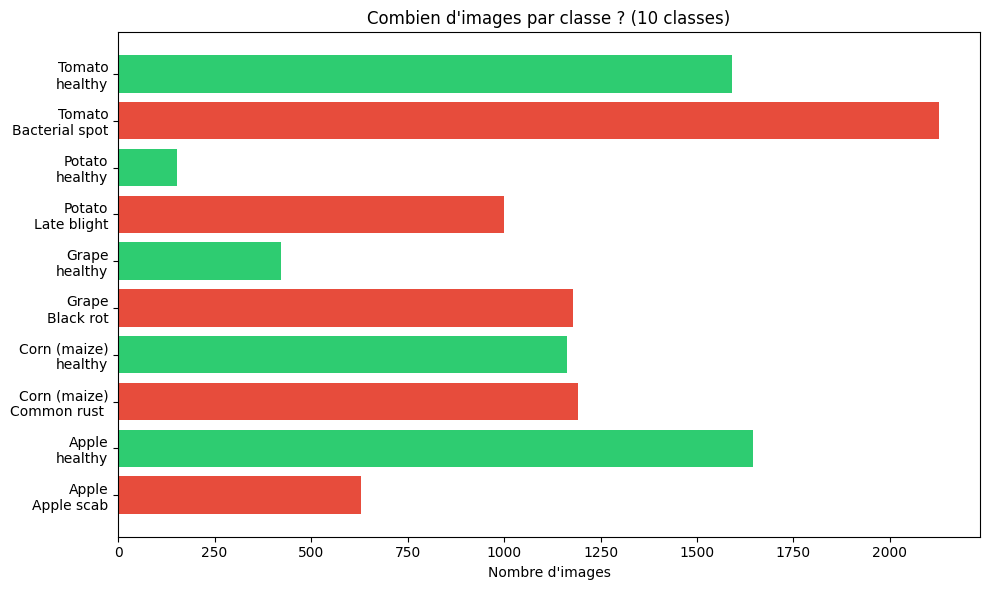

Au total : 11102 images
La classe la moins fournie a 152 images, la plus fournie 2127


In [23]:
import matplotlib.pyplot as plt

# On compte les images de chaque classe
compteur = {}
for nom in NOMS_CLASSES:
    compteur[nom] = len(list((SOUS_DATASET / nom).glob("*.*")))

plt.figure(figsize=(10, 6))
noms_courts = [n.replace("___", "\n").replace("_", " ") for n in NOMS_CLASSES]
couleurs = ["#2ecc71" if "healthy" in n else "#e74c3c" for n in NOMS_CLASSES]
plt.barh(noms_courts, list(compteur.values()), color=couleurs)
plt.xlabel("Nombre d'images")
plt.title(f"Combien d'images par classe ? ({NB_CLASSES} classes)")
plt.tight_layout()
plt.savefig("outputs_distribution.png", dpi=150)
plt.show()

total = sum(compteur.values())
print(f"Au total : {total} images")
print(f"La classe la moins fournie a {min(compteur.values())} images, la plus fournie {max(compteur.values())}")

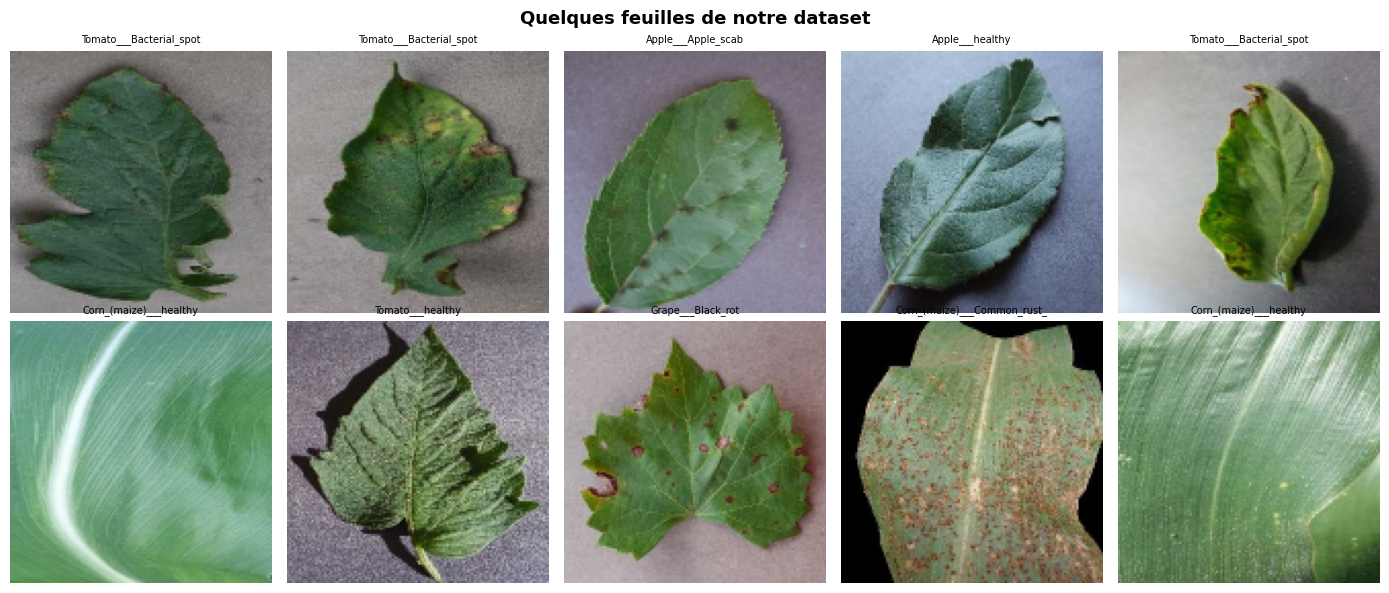

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(NOMS_CLASSES[labels[i]], fontsize=7)
        plt.axis("off")
plt.suptitle("Quelques feuilles de notre dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Data augmentation et fonctions reutilisables

La data augmentation est notre premiere technique de regularisation.

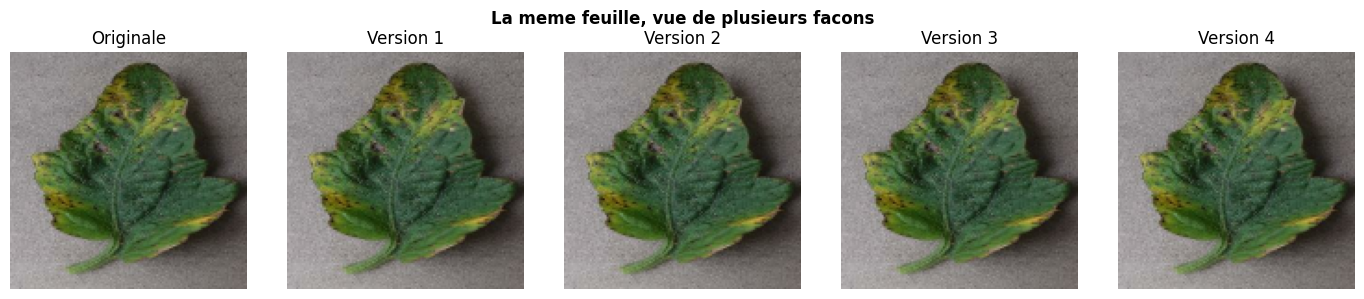

In [25]:
from tensorflow import keras
from tensorflow.keras import layers

# Bloc d'augmentation
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name="augmentation")

# On regarde l'effet de l'augmentation sur une meme image
plt.figure(figsize=(14, 3))
for images, _ in train_ds.take(1):
    image_test = images[0]
    plt.subplot(1, 5, 1)
    plt.imshow(image_test.numpy().astype("uint8"))
    plt.title("Originale")
    plt.axis("off")
    for i in range(2, 6):
        aug = augmentation(tf.expand_dims(image_test, 0))[0]
        plt.subplot(1, 5, i)
        plt.imshow(aug.numpy().astype("uint8"))
        plt.title(f"Version {i-1}")
        plt.axis("off")
plt.suptitle("La meme feuille, vue de plusieurs facons", fontweight="bold")
plt.tight_layout()
plt.show()

### Quelques outils qu'on va reutiliser pour chaque modele

Pour ne pas reecrire le meme code a chaque fois, on prepare trois petites fonctions : une pour les callbacks (early stopping + sauvegarde du meilleur modele), une pour evaluer un modele, et une pour tracer les courbes.

In [26]:
from tensorflow.keras import callbacks
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import seaborn as sns

# On stockera les scores de chaque modele ici pour les comparer a la fin
resultats = []


def mes_callbacks(nom_modele):
    """Callbacks communs : on s'arrete quand ca ne progresse plus,
    on reduit le learning rate si on stagne, et on garde le meilleur modele."""
    return [
        callbacks.EarlyStopping(
            monitor="val_accuracy", mode="max",
            patience=8, restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1,
        ),
        callbacks.ModelCheckpoint(
            f"models/best_{nom_modele}.keras",
            monitor="val_accuracy", mode="max",
            save_best_only=True, verbose=0,
        ),
    ]


def evaluer(model, dataset, nom_modele):
    """Calcule l'accuracy et le F1, affiche le rapport et la matrice de confusion."""
    vrais, predits = [], []
    for images, labels in dataset:
        proba = model.predict(images, verbose=0)
        predits.extend(np.argmax(proba, axis=1))
        vrais.extend(labels.numpy())
    vrais, predits = np.array(vrais), np.array(predits)

    acc = np.mean(vrais == predits)
    f1 = f1_score(vrais, predits, average="macro")

    print(f"\n----- {nom_modele} -----")
    print(f"Accuracy : {acc:.4f}  ({acc:.2%})")
    print(f"F1 macro : {f1:.4f}")

    noms = [n.replace("___", " ").replace("_", " ") for n in NOMS_CLASSES]
    print("\n", classification_report(vrais, predits, target_names=noms, digits=3))

    cm = confusion_matrix(vrais, predits)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=noms, yticklabels=noms)
    plt.xlabel("Predit")
    plt.ylabel("Vrai")
    plt.title(f"Matrice de confusion : {nom_modele}")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()

    resultats.append({"modele": nom_modele, "accuracy": acc, "f1": f1})
    return acc, f1


def tracer_courbes(historique, nom_modele):
    """Trace l'evolution de la loss et de l'accuracy au fil des epoques."""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(historique.history["loss"], label="Entrainement")
    plt.plot(historique.history["val_loss"], label="Validation")
    plt.title(f"{nom_modele} : evolution de la loss")
    plt.xlabel("Epoque"); plt.ylabel("Loss")
    plt.legend(); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(historique.history["accuracy"], label="Entrainement")
    plt.plot(historique.history["val_accuracy"], label="Validation")
    plt.title(f"{nom_modele} : evolution de l'accuracy")
    plt.xlabel("Epoque"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# On cree le dossier models pour les sauvegardes
import os
os.makedirs("models", exist_ok=True)

## 1. Premier modele : un reseau dense (MLP)

On commence par le modele le plus simple possible : on aplatit l'image en un grand vecteur

Pour la regularisation :
- regularisation ElasticNet (melange de L1 et L2) sur les poids
- initialisation He pour les couches ReLU, Glorot pour la sortie softmax
- on separe la couche Dense, le BatchNorm et l'activation (Dense puis BN puis ReLU)
- du Dropout entre les blocs

In [27]:
from tensorflow.keras import regularizers, initializers

# Les hyperparametres de regularisation
L1, L2 = 1e-6, 1e-4          
DROPOUT_1, DROPOUT_2 = 0.30, 0.40

# On prepare le regularisateur et les initialisations une bonne fois
elastic = regularizers.l1_l2(l1=L1, l2=L2)
init_he = initializers.HeNormal()          # bien adapte au ReLU
init_glorot = initializers.GlorotUniform() # pour la couche softmax finale


def construire_mlp():
    """Reseau dense avec la regularisation du TP : ElasticNet + BN + Dropout."""
    entree = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # On normalise les pixels de [0,255] vers [0,1] puis on augmente
    x = layers.Rescaling(1.0 / 255)(entree)
    x = augmentation(x)
    x = layers.Flatten()(x)

    # Premier bloc dense : Dense -> BatchNorm -> ReLU -> Dropout
    x = layers.Dense(512, kernel_initializer=init_he, kernel_regularizer=elastic)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(DROPOUT_1)(x)

    # Deuxieme bloc dense
    x = layers.Dense(128, kernel_initializer=init_he, kernel_regularizer=elastic)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(DROPOUT_2)(x)

    # Couche de sortie 
    sortie = layers.Dense(NB_CLASSES, activation="softmax",
                          kernel_initializer=init_glorot)(x)

    return keras.Model(entree, sortie, name="MLP_dense")


mlp = construire_mlp()
mlp.summary()

Model: "MLP_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 rescaling_4 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 augmentation (Sequential)   (None, 128, 128, 3)       0         
                                                                 
 flatten_2 (Flatten)         (None, 49152)             0         
                                                                 
 dense_9 (Dense)             (None, 512)               25166336  
                                                                 
 batch_normalization_12 (Bat  (None, 512)              2048      
 chNormalization)                                                
                                                         

c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


On lance l'entrainement du MLP...
Epoch 1/30
243/243 [==============================] - 121s 481ms/step - loss: 1.5714 - accuracy: 0.5970 - val_loss: 2.0389 - val_accuracy: 0.4183 - lr: 0.0010
Epoch 2/30
243/243 [==============================] - 126s 519ms/step - loss: 1.2189 - accuracy: 0.7054 - val_loss: 2.4579 - val_accuracy: 0.4567 - lr: 0.0010
Epoch 3/30
243/243 [==============================] - 119s 491ms/step - loss: 1.1207 - accuracy: 0.7320 - val_loss: 2.6709 - val_accuracy: 0.4549 - lr: 0.0010
Epoch 4/30
243/243 [==============================] - 121s 497ms/step - loss: 1.0906 - accuracy: 0.7410 - val_loss: 4.4414 - val_accuracy: 0.3546 - lr: 0.0010
Epoch 5/30
243/243 [==============================] - ETA: 0s - loss: 1.0855 - accuracy: 0.7410
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
243/243 [==============================] - 125s 516ms/step - loss: 1.0855 - accuracy: 0.7410 - val_loss: 3.9039 - val_accuracy: 0.4093 - lr: 0.0010
Epoch 6/30

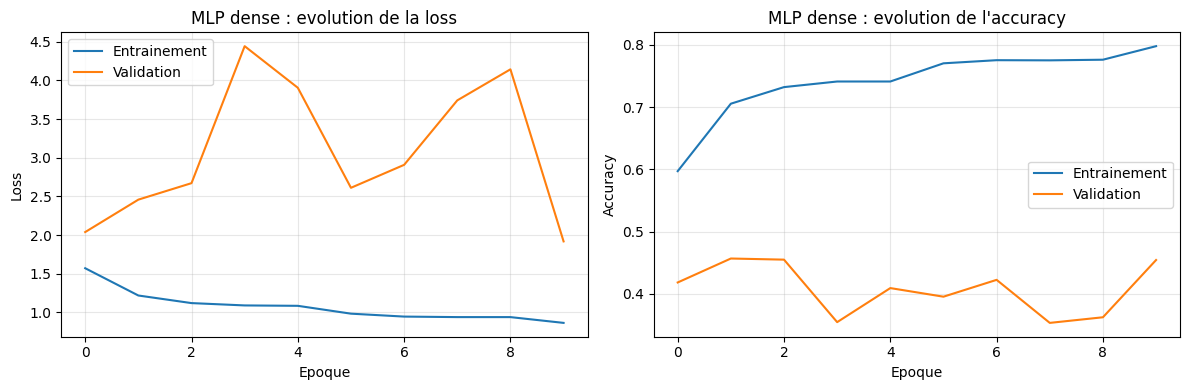


----- MLP dense -----
Accuracy : 0.4760  (47.60%)
F1 macro : 0.3447

                            precision    recall  f1-score   support

         Apple Apple scab      0.188     0.140     0.160        86
            Apple healthy      0.263     0.973     0.414       256
Corn (maize) Common rust       1.000     1.000     1.000       176
     Corn (maize) healthy      0.789     0.994     0.880       173
          Grape Black rot      0.683     0.612     0.646       183
            Grape healthy      0.000     0.000     0.000        57
       Potato Late blight      0.000     0.000     0.000       162
           Potato healthy      0.000     0.000     0.000        21
    Tomato Bacterial spot      0.750     0.226     0.348       318
           Tomato healthy      0.000     0.000     0.000       234

                 accuracy                          0.476      1666
                macro avg      0.367     0.394     0.345      1666
             weighted avg      0.456     0.476     0.406

c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

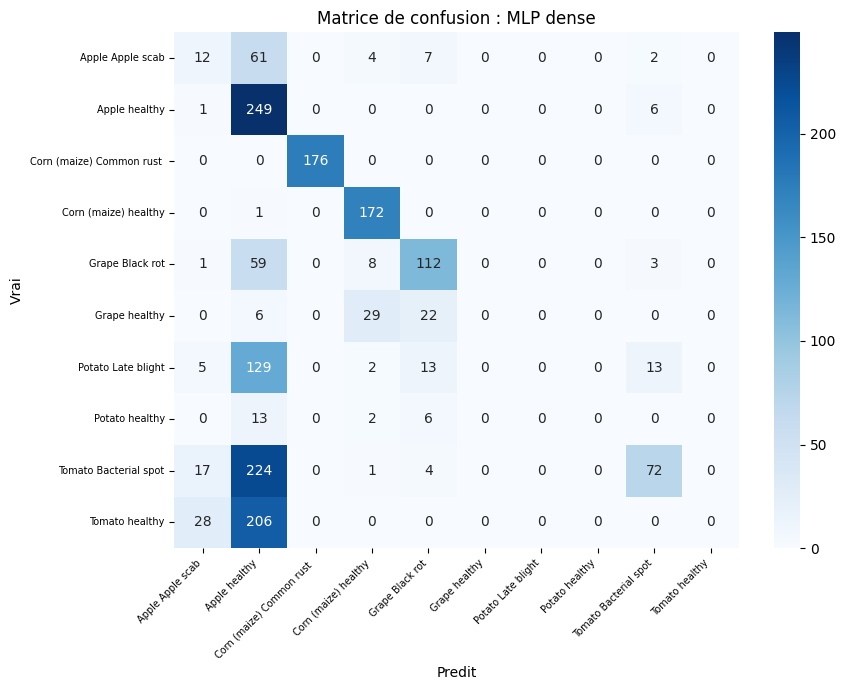

(0.4759903961584634, 0.3446775887044805)

In [28]:
mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("On lance l'entrainement du MLP...")
hist_mlp = mlp.fit(
    train_ds, validation_data=val_ds,
    epochs=30,
    callbacks=mes_callbacks("mlp"),
    verbose=1,
)

tracer_courbes(hist_mlp, "MLP dense")
evaluer(mlp, test_ds, "MLP dense")

## 2. Deuxieme modele : le CNN (et on compare deux versions)

Le CNN (reseau de neurones convolutif) est fait pour les images. On va entrainer deux versions pour bien voir la difference :

- Version A : un CNN basique, sans aucune regularisation
- Version B : le meme CNN mais avec regularisation

### Version A : CNN basique, sans regularisation

Entrainement du CNN simple...
Epoch 1/25
243/243 [==============================] - 10s 40ms/step - loss: 0.6578 - accuracy: 0.7831 - val_loss: 0.2748 - val_accuracy: 0.9099 - lr: 0.0010
Epoch 2/25
243/243 [==============================] - 9s 37ms/step - loss: 0.1930 - accuracy: 0.9322 - val_loss: 0.1835 - val_accuracy: 0.9381 - lr: 0.0010
Epoch 3/25
243/243 [==============================] - 9s 37ms/step - loss: 0.1189 - accuracy: 0.9610 - val_loss: 0.1746 - val_accuracy: 0.9429 - lr: 0.0010
Epoch 4/25
243/243 [==============================] - 9s 36ms/step - loss: 0.0900 - accuracy: 0.9698 - val_loss: 0.2501 - val_accuracy: 0.9165 - lr: 0.0010
Epoch 5/25
243/243 [==============================] - 9s 37ms/step - loss: 0.0669 - accuracy: 0.9766 - val_loss: 0.1250 - val_accuracy: 0.9615 - lr: 0.0010
Epoch 6/25
243/243 [==============================] - 9s 36ms/step - loss: 0.0615 - accuracy: 0.9797 - val_loss: 0.1581 - val_accuracy: 0.9525 - lr: 0.0010
Epoch 7/25
243/243 [=============

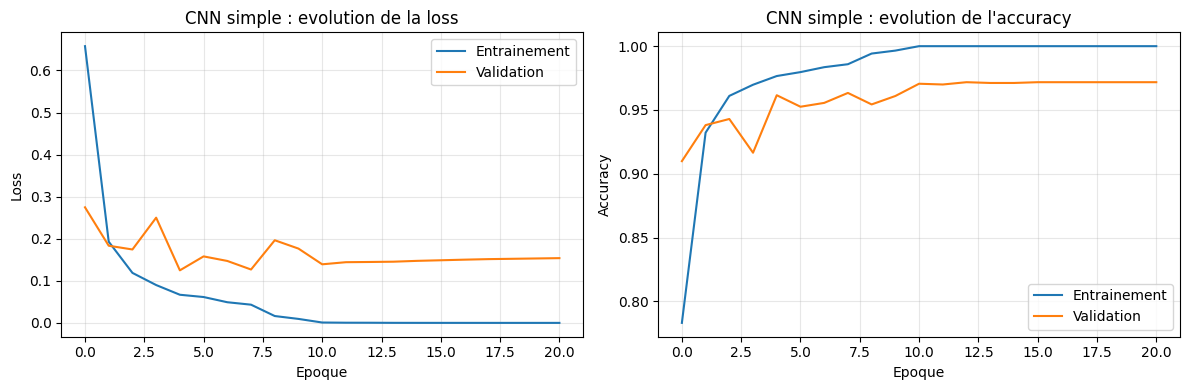


----- CNN simple -----
Accuracy : 0.9784  (97.84%)
F1 macro : 0.9554

                            precision    recall  f1-score   support

         Apple Apple scab      0.939     0.895     0.917        86
            Apple healthy      0.954     0.980     0.967       256
Corn (maize) Common rust       1.000     0.994     0.997       176
     Corn (maize) healthy      0.994     1.000     0.997       173
          Grape Black rot      0.958     0.995     0.976       183
            Grape healthy      0.982     0.947     0.964        57
       Potato Late blight      0.968     0.932     0.950       162
           Potato healthy      0.882     0.714     0.789        21
    Tomato Bacterial spot      0.994     1.000     0.997       318
           Tomato healthy      1.000     1.000     1.000       234

                 accuracy                          0.978      1666
                macro avg      0.967     0.946     0.955      1666
             weighted avg      0.978     0.978     0.97

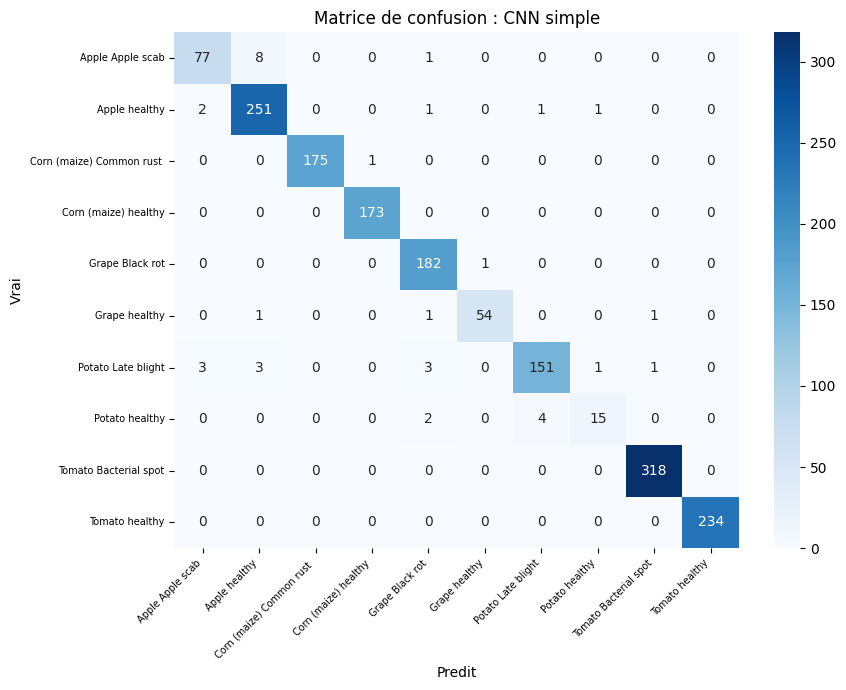

(0.978391356542617, 0.9554361971308121)

In [29]:
def construire_cnn_simple():
    
    return keras.Sequential([
        layers.Rescaling(1.0 / 255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(NB_CLASSES, activation="softmax"),
    ], name="CNN_simple")


cnn_simple = construire_cnn_simple()
cnn_simple.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Entrainement du CNN simple...")
hist_cnn_simple = cnn_simple.fit(
    train_ds, validation_data=val_ds,
    epochs=25,
    callbacks=mes_callbacks("cnn_simple"),
    verbose=1,
)

tracer_courbes(hist_cnn_simple, "CNN simple")
evaluer(cnn_simple, test_ds, "CNN simple")

### Version B : CNN avec regularisation

Ici on régularise :
- augmentation des donnees en entree
- pour chaque bloc : Conv puis BatchNorm puis activation
- Dropout apres chaque bloc
- ElasticNet sur les couches denses
- GlobalAveragePooling au lieu de Flatten (ca reduit beaucoup le nombre de parametres, donc moins de risque de sur-apprentissage)
- initialisation He

In [30]:
def construire_cnn_regularise():
    "Le meme CNN, mais avec toutes les techniques de regularisation du TP."
    entree = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Rescaling(1.0 / 255)(entree)
    x = augmentation(x)

    # Bloc 1 : Conv -> BN -> ReLU -> Pool -> Dropout
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_initializer=init_he)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloc 2
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_initializer=init_he)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloc 3
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_initializer=init_he)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloc 4
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_initializer=init_he)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # GlobalAveragePooling : remplace Flatten, beaucoup plus leger (conseillé par l'IA)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_initializer=init_he, kernel_regularizer=elastic)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)

    sortie = layers.Dense(NB_CLASSES, activation="softmax",
                          kernel_initializer=init_glorot)(x)

    return keras.Model(entree, sortie, name="CNN_regularise")


cnn_reg = construire_cnn_regularise()
cnn_reg.summary()

c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(
c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


Model: "CNN_regularise"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 rescaling_6 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 augmentation (Sequential)   (None, 128, 128, 3)       0         
                                                                 
 conv2d_14 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 batch_normalization_14 (Bat  (None, 128, 128, 32)     128       
 chNormalization)                                                
                                                                 
 activation_14 (Activation)  (None, 128, 128, 32)      0         
                                                    

Entrainement du CNN regularise...
Epoch 1/40
243/243 [==============================] - 156s 617ms/step - loss: 0.8483 - accuracy: 0.7371 - val_loss: 1.5315 - val_accuracy: 0.5679 - lr: 0.0010
Epoch 2/40
243/243 [==============================] - 140s 575ms/step - loss: 0.5242 - accuracy: 0.8385 - val_loss: 0.8010 - val_accuracy: 0.7524 - lr: 0.0010
Epoch 3/40
243/243 [==============================] - 136s 558ms/step - loss: 0.4309 - accuracy: 0.8679 - val_loss: 1.1299 - val_accuracy: 0.7320 - lr: 0.0010
Epoch 4/40
243/243 [==============================] - 133s 549ms/step - loss: 0.3787 - accuracy: 0.8918 - val_loss: 1.6600 - val_accuracy: 0.6460 - lr: 0.0010
Epoch 5/40
243/243 [==============================] - 135s 557ms/step - loss: 0.3423 - accuracy: 0.9013 - val_loss: 1.3891 - val_accuracy: 0.7200 - lr: 0.0010
Epoch 6/40
243/243 [==============================] - ETA: 0s - loss: 0.3270 - accuracy: 0.9025
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

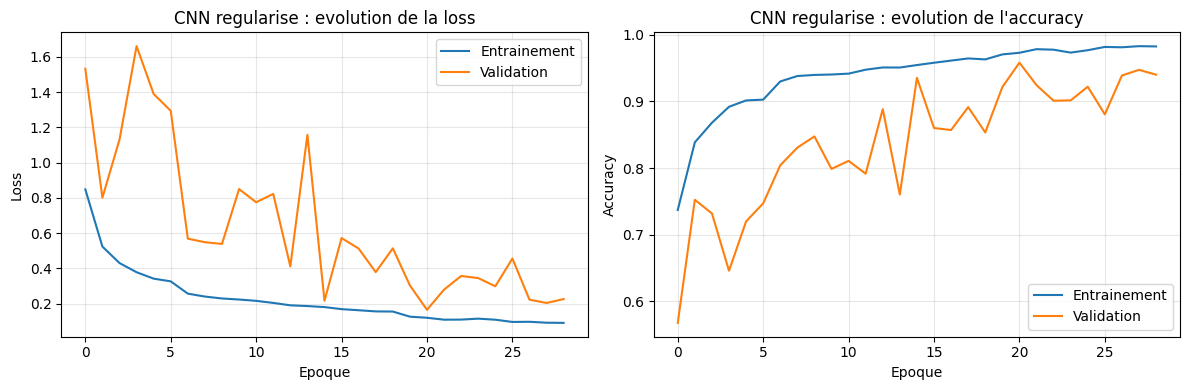


----- CNN regularise -----
Accuracy : 0.9598  (95.98%)
F1 macro : 0.9487

                            precision    recall  f1-score   support

         Apple Apple scab      0.934     0.826     0.877        86
            Apple healthy      0.996     0.871     0.929       256
Corn (maize) Common rust       1.000     1.000     1.000       176
     Corn (maize) healthy      1.000     1.000     1.000       173
          Grape Black rot      1.000     0.945     0.972       183
            Grape healthy      0.966     0.982     0.974        57
       Potato Late blight      0.868     0.975     0.919       162
           Potato healthy      0.900     0.857     0.878        21
    Tomato Bacterial spot      0.952     0.997     0.974       318
           Tomato healthy      0.932     1.000     0.965       234

                 accuracy                          0.960      1666
                macro avg      0.955     0.945     0.949      1666
             weighted avg      0.962     0.960     

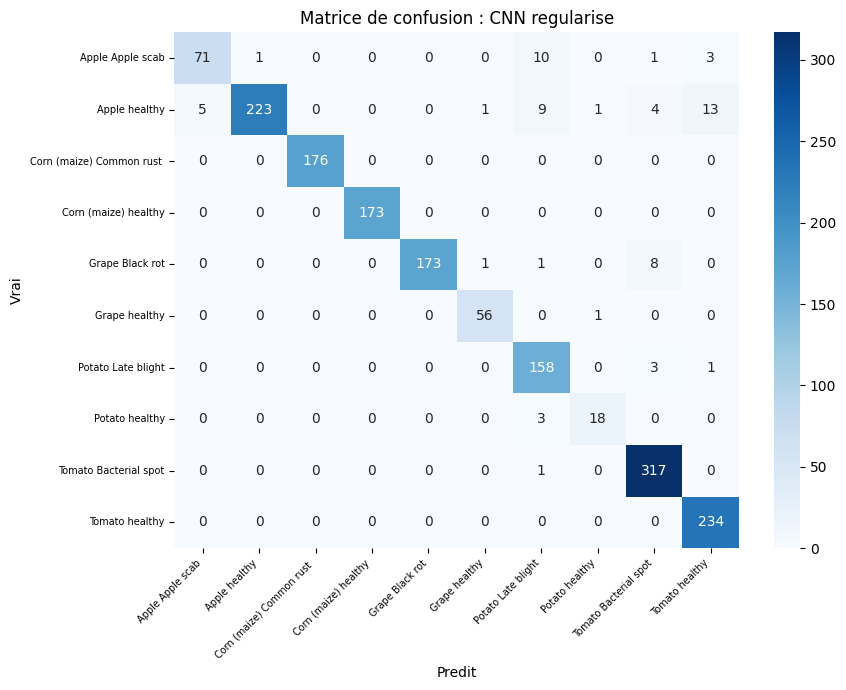

(0.9597839135654261, 0.9487021246364902)

In [31]:
cnn_reg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Entrainement du CNN regularise...")
hist_cnn_reg = cnn_reg.fit(
    train_ds, validation_data=val_ds,
    epochs=40,
    callbacks=mes_callbacks("cnn_reg"),
    verbose=1,
)

tracer_courbes(hist_cnn_reg, "CNN regularise")
evaluer(cnn_reg, test_ds, "CNN regularise")

### Comparaison des deux CNN

On superpose les courbes pour bien voir l'effet de la regularisation.

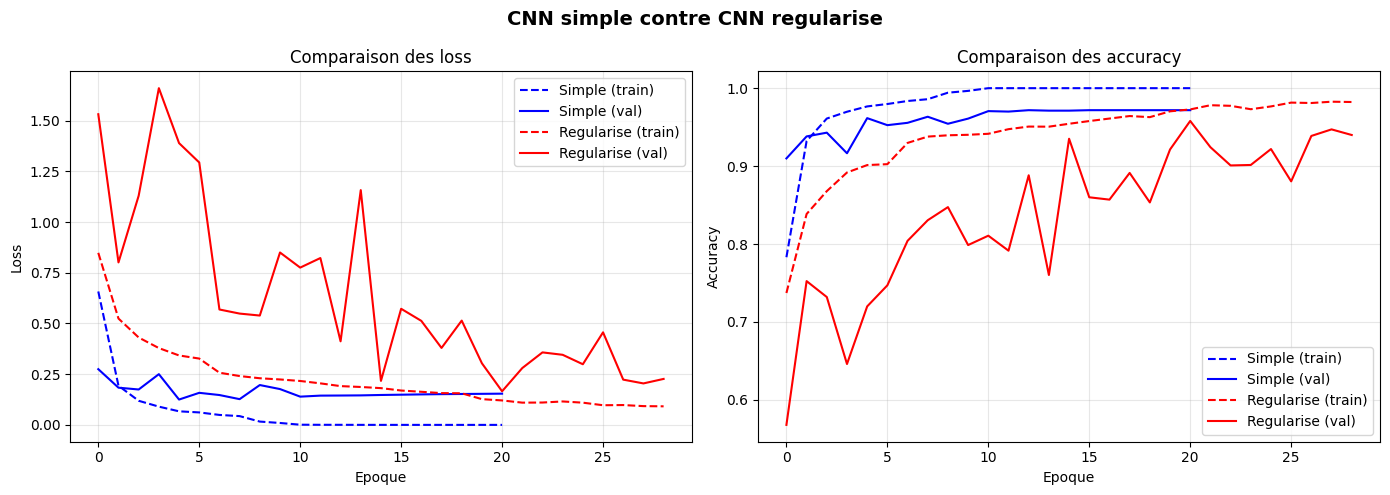

Ce qu'on observe en general :
- le CNN simple a un gros ecart train/val, signe qu'il sur-apprend
- le CNN regularise a des courbes plus proches, il generalise mieux


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_cnn_simple.history["loss"], "b--", label="Simple (train)")
plt.plot(hist_cnn_simple.history["val_loss"], "b-", label="Simple (val)")
plt.plot(hist_cnn_reg.history["loss"], "r--", label="Regularise (train)")
plt.plot(hist_cnn_reg.history["val_loss"], "r-", label="Regularise (val)")
plt.title("Comparaison des loss")
plt.xlabel("Epoque"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(hist_cnn_simple.history["accuracy"], "b--", label="Simple (train)")
plt.plot(hist_cnn_simple.history["val_accuracy"], "b-", label="Simple (val)")
plt.plot(hist_cnn_reg.history["accuracy"], "r--", label="Regularise (train)")
plt.plot(hist_cnn_reg.history["val_accuracy"], "r-", label="Regularise (val)")
plt.title("Comparaison des accuracy")
plt.xlabel("Epoque"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(alpha=0.3)

plt.suptitle("CNN simple contre CNN regularise", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


le CNN simple surfit légèrement mais performe mieux ici car le dataset est assez petit et propre. Le régularisé a un comportement plus sain (pas de surapprentissage) mais aurait besoin de plus d'époques ou d'un Dropout légèrement réduit pour atteindre son potentiel.

## 3. Troisieme modele : un ResNet 
Le ResNet introduit les **connexions residuelles**.

In [33]:
def bloc_residuel(x, nb_filtres, stride=1):
    """Un bloc residuel facon ResNet.

    On passe l'entree dans deux convolutions, et en parallele on garde
    un raccourci (le shortcut). A la fin, on additionne les deux.
    Si la taille change, on ajuste le raccourci avec une conv 1x1.
    """
    raccourci = x

    x = layers.Conv2D(nb_filtres, (3, 3), strides=stride, padding="same",
                      kernel_initializer=init_he, kernel_regularizer=elastic)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(nb_filtres, (3, 3), strides=1, padding="same",
                      kernel_initializer=init_he, kernel_regularizer=elastic)(x)
    x = layers.BatchNormalization()(x)

    # Si les dimensions ont change, on adapte le raccourci
    if stride > 1 or raccourci.shape[-1] != nb_filtres:
        raccourci = layers.Conv2D(nb_filtres, (1, 1), strides=stride, padding="same",
                                  kernel_initializer=init_he)(raccourci)
        raccourci = layers.BatchNormalization()(raccourci)

    # Le coeur du ResNet : on additionne le chemin principal et le raccourci
    x = layers.Add()([x, raccourci])
    x = layers.Activation("relu")(x)
    return x


def construire_resnet():
    "ResNet, une conv d'entree, puis trois groupes de blocs residuels"
    entree = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Rescaling(1.0 / 255)(entree)
    x = augmentation(x)

    x = layers.Conv2D(64, (7, 7), strides=2, padding="same",
                      kernel_initializer=init_he)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same")(x)

    x = bloc_residuel(x, 64)
    x = bloc_residuel(x, 64)

    x = bloc_residuel(x, 128, stride=2)
    x = bloc_residuel(x, 128)

    x = bloc_residuel(x, 256, stride=2)
    x = bloc_residuel(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    sortie = layers.Dense(NB_CLASSES, activation="softmax",
                          kernel_initializer=init_glorot)(x)

    return keras.Model(entree, sortie, name="ResNet_maison")


resnet = construire_resnet()
resnet.summary()

c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


Model: "ResNet_maison"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_7 (Rescaling)        (None, 128, 128, 3)  0           ['input_6[0][0]']                
                                                                                                  
 augmentation (Sequential)      (None, 128, 128, 3)  0           ['rescaling_7[0][0]']            
                                                                                                  
 conv2d_18 (Conv2D)             (None, 64, 64, 64)   9472        ['augmentation[2][0]'

c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


                                                                                                  
 batch_normalization_25 (BatchN  (None, 16, 16, 128)  512        ['conv2d_24[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_26 (BatchN  (None, 16, 16, 128)  512        ['conv2d_25[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 add_2 (Add)                    (None, 16, 16, 128)  0           ['batch_normalization_25[0][0]', 
                                                                  'batch_normalization_26[0][0]'] 
                                                                                                  
 activatio

Entrainement du ResNet (ca peut prendre un peu de temps)...
Epoch 1/40
243/243 [==============================] - 176s 678ms/step - loss: 1.3716 - accuracy: 0.7074 - val_loss: 2.6874 - val_accuracy: 0.4868 - lr: 0.0010
Epoch 2/40
243/243 [==============================] - 160s 660ms/step - loss: 0.9788 - accuracy: 0.8136 - val_loss: 1.1203 - val_accuracy: 0.7770 - lr: 0.0010
Epoch 3/40
243/243 [==============================] - 166s 683ms/step - loss: 0.8217 - accuracy: 0.8556 - val_loss: 1.9343 - val_accuracy: 0.5980 - lr: 0.0010
Epoch 4/40
243/243 [==============================] - 138s 569ms/step - loss: 0.7227 - accuracy: 0.8729 - val_loss: 6.5668 - val_accuracy: 0.4267 - lr: 0.0010
Epoch 5/40
243/243 [==============================] - 127s 520ms/step - loss: 0.6608 - accuracy: 0.8870 - val_loss: 3.7009 - val_accuracy: 0.5054 - lr: 0.0010
Epoch 6/40
243/243 [==============================] - ETA: 0s - loss: 0.5746 - accuracy: 0.9043
Epoch 6: ReduceLROnPlateau reducing learning rate

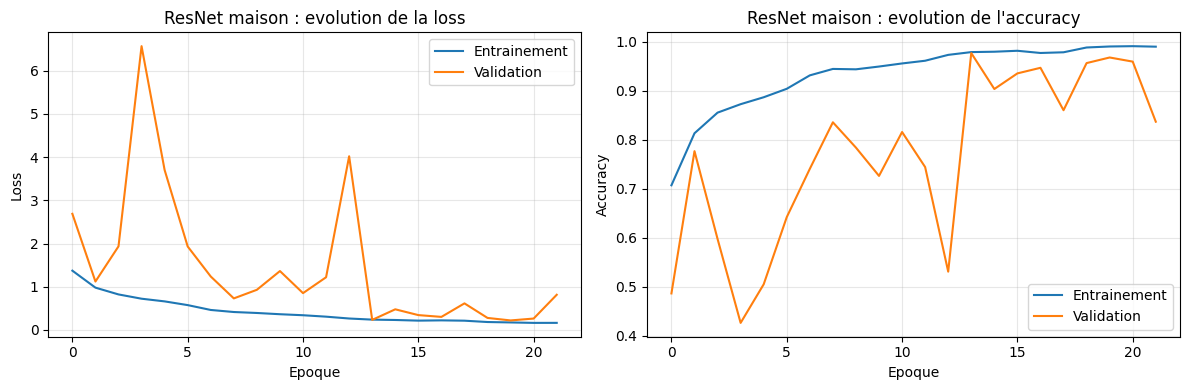


----- ResNet maison -----
Accuracy : 0.9730  (97.30%)
F1 macro : 0.9468

                            precision    recall  f1-score   support

         Apple Apple scab      0.842     0.988     0.909        86
            Apple healthy      0.988     0.945     0.966       256
Corn (maize) Common rust       1.000     1.000     1.000       176
     Corn (maize) healthy      1.000     1.000     1.000       173
          Grape Black rot      1.000     0.956     0.978       183
            Grape healthy      1.000     0.877     0.935        57
       Potato Late blight      0.930     0.981     0.955       162
           Potato healthy      0.875     0.667     0.757        21
    Tomato Bacterial spot      0.987     0.984     0.986       318
           Tomato healthy      0.967     1.000     0.983       234

                 accuracy                          0.973      1666
                macro avg      0.959     0.940     0.947      1666
             weighted avg      0.974     0.973     0

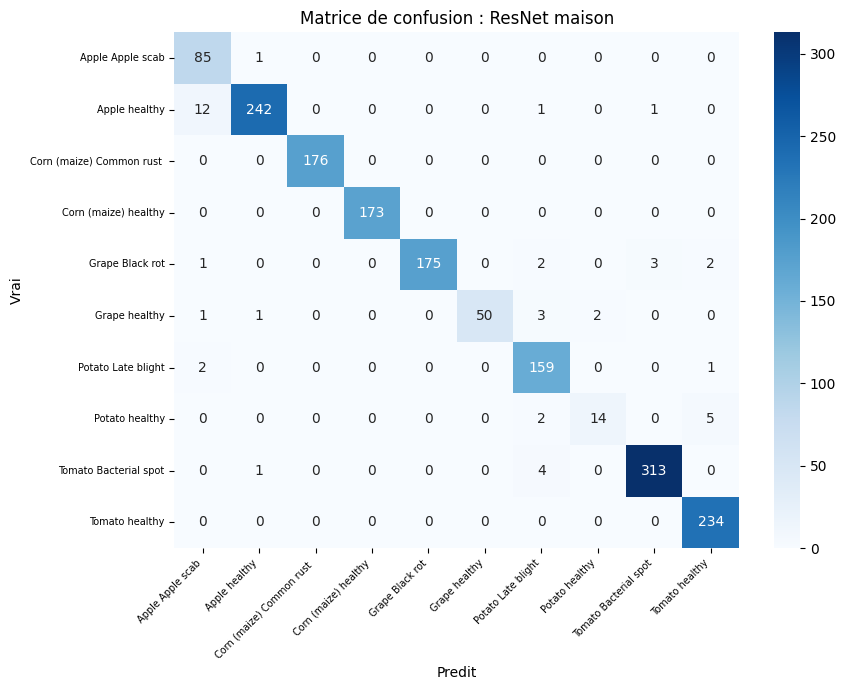

(0.9729891956782714, 0.9468123604575798)

In [34]:
resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Entrainement du ResNet (ca peut prendre un peu de temps)...")
hist_resnet = resnet.fit(
    train_ds, validation_data=val_ds,
    epochs=40,
    callbacks=mes_callbacks("resnet"),
    verbose=1,
)

tracer_courbes(hist_resnet, "ResNet maison")
evaluer(resnet, test_ds, "ResNet maison")

## 4. Quatrieme modele : le transfer learning

on utilise **DenseNet121** de HF:
- on charge DenseNet121 pre-entraine, sans sa tete de classification
- on gele ses poids (on ne veut pas les casser)
- on ajoute notre propre tete (GlobalAveragePooling, BatchNorm, Dense, Dropout)
- on entraine, puis on degele un peu pour affiner

In [35]:
# On charge DenseNet121 pre-entraine 
base = keras.applications.DenseNet121(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,       # on enleve la tete d'origine (1000 classes ImageNet)
    weights="imagenet",
)

base.trainable = False  # on gele pour commencer
print(f"DenseNet121 charge : {len(base.layers)} couches, gelees pour commencer")

# On construit notre modele complet par-dessus
entree = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Rescaling(1.0 / 255)(entree)
x = augmentation(x)
x = base(x, training=False)

# Notre tete de classification
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(64, activation="relu", kernel_initializer=init_he)(x)
x = layers.Dropout(0.3)(x)
sortie = layers.Dense(NB_CLASSES, activation="softmax", kernel_initializer=init_glorot)(x)

transfer = keras.Model(entree, sortie, name="DenseNet_transfer")
transfer.summary()

29084464/29084464 [==============================] - 3s 0us/step
DenseNet121 charge : 427 couches, gelees pour commencer
Model: "DenseNet_transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 rescaling_8 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 augmentation (Sequential)   (None, 128, 128, 3)       0         
                                                                 
 densenet121 (Functional)    (None, 4, 4, 1024)        7037504   
                                                                 
 global_average_pooling2d_4   (None, 1024)             0         
 (GlobalAveragePooling2D)                                        
                                                            

c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(
c:\Users\STE\Documents\Cours Efrei\Deep Learning\Projet Plant\venv\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [ ]:
# Phase 1 : on n'entraine que notre tete, le DenseNet reste gele
transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Phase 1 : on entraine seulement la tete de classification")
hist_tl_1 = transfer.fit(
    train_ds, validation_data=val_ds,
    epochs=10,
    callbacks=mes_callbacks("transfer_p1"),
    verbose=1,
)

NameError: name 'transfer' is not defined

: 

In [1]:
# Phase 2 : on degele les dernieres couches du DenseNet pour les affiner.
# On utilise un learning rate beaucoup plus petit pour ne pas tout casser.
base.trainable = True
for couche in base.layers[:-30]:   # on garde gelé toutes les couches sauf les 30 dernieres
    couche.trainable = False

transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Phase 2 : fine-tuning des dernieres couches de DenseNet")
hist_tl_2 = transfer.fit(
    train_ds, validation_data=val_ds,
    epochs=15,
    callbacks=mes_callbacks("transfer_p2"),
    verbose=1,
)

# On recolle les deux historiques pour tracer une seule courbe continue
hist_complet = type(hist_tl_1)()
hist_complet.history = {
    cle: hist_tl_1.history[cle] + hist_tl_2.history[cle]
    for cle in hist_tl_1.history
}
tracer_courbes(hist_complet, "Transfer Learning DenseNet")
evaluer(transfer, test_ds, "Transfer Learning DenseNet")

NameError: name 'base' is not defined

## Le bilan : on compare tous les modeles

C'est le moment de voir lequel s'en sort le mieux.

In [ ]:
print("Classement de nos modeles :\n")
print(f"{'Modele':<28} {'Accuracy':>10} {'F1 macro':>10}")
print("-" * 50)
for r in sorted(resultats, key=lambda d: d["accuracy"], reverse=True):
    print(f"{r['modele']:<28} {r['accuracy']:>10.4f} {r['f1']:>10.4f}")

noms = [r["modele"] for r in resultats]
accs = [r["accuracy"] for r in resultats]
f1s = [r["f1"] for r in resultats]

x = np.arange(len(noms))
largeur = 0.35
plt.figure(figsize=(11, 6))
b1 = plt.bar(x - largeur/2, accs, largeur, label="Accuracy", color="#3498db")
b2 = plt.bar(x + largeur/2, f1s, largeur, label="F1 macro", color="#e74c3c")
plt.ylabel("Score")
plt.title("Comparaison de tous les modeles", fontweight="bold")
plt.xticks(x, noms, rotation=20, ha="right", fontsize=9)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)
for barre in list(b1) + list(b2):
    plt.text(barre.get_x() + barre.get_width()/2, barre.get_height() + 0.01,
             f"{barre.get_height():.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("outputs_comparaison.png", dpi=150)
plt.show()

## Recapitulatif des techniques de regularisation

Voici toutes les techniques utilisees dans ce notebook, inspirées de mon TP de CNN :

| Technique | utilisé où | A quoi ca sert |
|-----------|-----|----------------|
| **Data augmentation** | Tous (sauf CNN simple) | Cree des variantes des images, le modele ne memorise pas par coeur |
| **ElasticNet (L1 + L2)** | MLP, CNN reg, ResNet | Penalise les poids trop gros, garde un modele simple |
| **BatchNormalization** | MLP, CNN reg, ResNet, TL | Normalise les activations, stabilise et accelere l'entrainement |
| **Dropout** | Tous (sauf CNN simple) | Eteint des neurones au hasard, evite qu'ils se reposent les uns sur les autres |
| **Initialisation He** | Couches ReLU | Demarre l'entrainement avec de bons poids de depart |
| **GlobalAveragePooling** | CNN reg, ResNet | Remplace Flatten, divise par beaucoup le nombre de parametres |
| **EarlyStopping** | Tous | Arrete quand ca ne progresse plus, garde le meilleur modele |
| **ReduceLROnPlateau** | Tous | Baisse le learning rate quand on stagne, pour affiner |
| **ModelCheckpoint** | Tous | Sauvegarde automatiquement le meilleur modele |
| **Skip connections** | ResNet | Aide le gradient a circuler dans un reseau profond |
| **Transfer learning** | DenseNet | Reutilise un modele deja entraine, gros gain de temps |

## Sauvegarde du meilleur modele


In [ ]:
# Je retrouve le meilleur modele
meilleur = max(resultats, key=lambda d: d["accuracy"])
print(f"Le grand gagnant : {meilleur['modele']} avec {meilleur['accuracy']:.2%} d'accuracy")

# Je fait une sauvegarde propre du modele gagnant
correspondance = {
    "MLP dense": mlp,
    "CNN simple": cnn_simple,
    "CNN regularise": cnn_reg,
    "ResNet maison": resnet,
    "Transfer Learning DenseNet": transfer,
}

modele_gagnant = correspondance[meilleur["modele"]]
modele_gagnant.save("models/modele_final.keras")
print("Modele sauvegarde sous : models/modele_final.keras")

# Je sauvegarde aussi la liste des classes, pour l'app Streamlit
import json
with open("models/classes.json", "w") as f:
    json.dump(NOMS_CLASSES, f)
print("Liste des classes sauvegardee sous : models/classes.json")